# Лабораторная работа 9

Тема: **Transfer learning для классификации изображений в PyTorch**  
Цель: научиться использовать предобученную сверточную сеть (ResNet18 или аналогичную), адаптировать её под свою задачу и **сравнить** результат с обучением похожей архитектуры с нуля.

> Важно: этот ноутбук сделан как задание, а не как готовый отчёт.  
> Код даёт стартовую точку, но основная часть баллов — за ваши эксперименты и ваши живые комментарии.  
> Текстовые ответы должны соответствовать вашим графикам и числам, а не быть универсальными фразами из интернета.


## 1. Ваше предварительное понимание transfer learning

Перед кодом сформулируйте своими словами:
1. Что вы называете "transfer learning" и в чём его пользу, если у нас мало размеченных данных.  
2. Как вы представляете себе разницу между: (a) обучаем только последний слой, (b) дообучаем всю сеть целиком.  
3. Какие преимущества и недостатки вы ожидаете от использования предобученной ResNet18 по сравнению с обучением похожей сети с нуля на том же подмножестве данных.

Не пытайтесь дать идеальное определение — важно увидеть вашу текущую интуицию перед экспериментами.


In [ ]:
intro_text = """1. Transfer learning - это когда мы берём уже обученную модель (например, на большом датасете)и используем её для новой задачи. Это особенно полезно, когда у нас мало данных, потому что модель уже умеет выделять базовые признаки (например, края, текстуры).
2. Если обучаем только последний слой, то мы фактически используем готовые признаки и просто подгоняем классификатор под новую задачу. Это быстрее и меньше риск переобучения.Если дообучаем всю сеть, то модель может лучше адаптироваться к новым данным, но есть риск переобучения и требуется больше времени.
3. Предобученная ResNet18 должна работать лучше, чем обучение с нуля на маленьком датасете, потому что она уже видела много изображений. У У нее быстрее сходимость и лучшее качество, но она может быть избыточной и не идеально подходить под конкретную задачу.
"""
print(intro_text)

1. Transfer learning - это когда мы берём уже обученную модель (например, на большом датасете)и используем её для новой задачи. Это особенно полезно, когда у нас мало данных, потому что модель уже умеет выделять базовые признаки (например, края, текстуры).
2. Если обучаем только последний слой, то мы фактически используем готовые признаки и просто подгоняем классификатор под новую задачу. Это быстрее и меньше риск переобучения.Если дообучаем всю сеть, то модель может лучше адаптироваться к новым данным, но есть риск переобучения и требуется больше времени.
3. Предобученная ResNet18 должна работать лучше, чем обучение с нуля на маленьком датасете, потому что она уже видела много изображений. У У нее быстрее сходимость и лучшее качество, но она может быть избыточной и не идеально подходить под конкретную задачу.



## 2. Импорт библиотек и настройка среды

Подготовка:
- импорт PyTorch и torchvision (включая готовые модели);
- фиксация seed;
- выбор устройства (`cpu` / `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import random
import matplotlib.pyplot as plt

MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные: подмножество CIFAR‑10 и аугментации

Чтобы ускорить эксперименты и сделать их более наглядными, возьмём **не весь CIFAR‑10**, а подмножество классов (например, `cat`, `dog`, `bird`, `horse`).

Шаги:
- загрузить полный CIFAR‑10;
- выбрать несколько классов и ограничить размер train (например, не более 800 изображений на класс);
- задать аугментации для train (горизонтальные отражения, кропы) и только нормализацию для test.


In [2]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
full_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

all_classes = full_train.classes
print("Все классы CIFAR‑10:", all_classes)

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


Все классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Выберем несколько классов (в примере — четыре).  
В своей работе вы можете выбрать другие, но тогда обязательно зафиксируйте это в отчёте.


In [3]:
selected_class_names = ["cat", "dog", "bird", "horse"]
class_to_idx_full = {name: i for i, name in enumerate(all_classes)}
selected_class_indices = {class_to_idx_full[name] for name in selected_class_names}

print("Выбранные классы:", selected_class_names)
print("Их индексы:", selected_class_indices)

Выбранные классы: ['cat', 'dog', 'bird', 'horse']
Их индексы: {2, 3, 5, 7}


In [12]:
def subset_by_classes(dataset, selected_idx_set, max_per_class=None):
    indices = []
    counts = {c: 0 for c in selected_idx_set}
    for i, (_, label) in enumerate(dataset):
        if label in selected_idx_set:
            if max_per_class is None or counts[label] < max_per_class:
                indices.append(i)
                counts[label] += 1
    return Subset(dataset, indices)

train_subset = subset_by_classes(full_train, selected_class_indices, max_per_class=800)
test_subset = subset_by_classes(full_test, selected_class_indices, max_per_class=None)

train_loader = DataLoader(train_subset, batch_size=None, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=None, shuffle=False)

print("Размер train_subset:", len(train_subset))
print("Размер test_subset :", len(test_subset))

Размер train_subset: 3200
Размер test_subset : 4000


Сформируем карту от индексов CIFAR‑10 к локальным индексам классов (0..K−1), чтобы правильно использовать `CrossEntropyLoss`.


In [5]:
selected_idx_sorted = sorted(list(selected_class_indices))
cifar_idx_to_local = {cifar_idx: i for i, cifar_idx in enumerate(selected_idx_sorted)}
local_to_name = {i: all_classes[cifar_idx] for i, cifar_idx in enumerate(selected_idx_sorted)}

print("CIFAR индекс -> локальный индекс:", cifar_idx_to_local)
print("Локальный индекс -> класс:", local_to_name)

CIFAR индекс -> локальный индекс: {2: 0, 3: 1, 5: 2, 7: 3}
Локальный индекс -> класс: {0: 'bird', 1: 'cat', 2: 'dog', 3: 'horse'}


## 4. Предобученная модель: ResNet18 и заморозка слоёв

Используем `torchvision.models.resnet18` с предобученными весами (`ImageNet`).  
Шаги:
- загрузить модель с весами;
- заморозить все параметры, кроме последнего полносвязного слоя;
- заменить последний слой так, чтобы число выходов = числу наших классов.


In [13]:
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# "Замораживаем" все параметры
for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.fc.in_features
num_target_classes = len(selected_class_indices)

base_model.fc = nn.Linear(num_ftrs, num_target_classes)
model_tl = base_model.to(device)
print(model_tl.fc)

Linear(in_features=512, out_features=4, bias=True)


### Комментарий: почему мы замораживаем слои?

Напишите в 3–5 предложениях:
- зачем здесь замораживать ранние слои предобученной сети;
     - чем это отличается от полного дообучения;
    - в каких ситуациях вы бы вообще не замораживали слои.


In [ ]:
freeze_comment = """Замораживание ранних слоев нужно, потому что они уже обучены на большом датасете и умеют выделять базовые признаки изображений, например контуры и текстуры. В таком случае мы обучаем только последний слой, чтобы быстрее подстроить модель под новые классы и снизить риск переобучения на маленьком наборе данных.
Это отличается от полного дообучения тем, что при полной настройке меняются веса всей сети, а значит модель сильнее адаптируется к новой задаче, но требует больше данных и времени.
Я бы не замораживала слои, если данных достаточно много или если новая задача сильно отличается от той, на которой модель обучали изначально."""
print(freeze_comment)

Замораживание ранних слоев нужно, потому что они уже обучены на большом датасете и умеют выделять базовые признаки изображений, например контуры и текстуры. В таком случае мы обучаем только последний слой, чтобы быстрее подстроить модель под новые классы и снизить риск переобучения на маленьком наборе данных.
Это отличается от полного дообучения тем, что при полной настройке меняются веса всей сети, а значит модель сильнее адаптируется к новой задаче, но требует больше данных и времени.
Я бы не замораживала слои, если данных достаточно много или если новая задача сильно отличается от той, на которой модель обучали изначально.


## 5. Функции обучения/оценки для transfer learning

Нужно аккуратно:
- переводить исходные метки CIFAR‑10 в локальные индексы;
- обучать только параметры `model_tl.fc`.


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

def map_labels_to_local(labels_tensor):
    mapped = [cifar_idx_to_local[int(l)] for l in labels_tensor]
    return torch.tensor(mapped, dtype=torch.long)

def train_one_epoch_tl(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_tl(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_local).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch_tl и evaluate_tl определены.")

Функции train_one_epoch_tl и evaluate_tl определены.


## 6. Обучение: transfer learning (только последний слой)

Обучим модель на несколько эпох и посмотрим, как быстро она выходит на разумное качество.


In [15]:
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)
num_epochs_tl = 8
history_tl = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_tl + 1):
    train_loss, train_acc = train_one_epoch_tl(model_tl, train_loader, optimizer_tl, criterion, device)
    test_loss, test_acc = evaluate_tl(model_tl, test_loader, criterion, device)

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)
    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(f"[TL] Эпоха {epoch}/{num_epochs_tl}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[TL] Эпоха 1/8: train_loss=1.3708, train_acc=0.3684, test_loss=1.2833, test_acc=0.4600
[TL] Эпоха 2/8: train_loss=1.2416, train_acc=0.4428, test_loss=1.2067, test_acc=0.4918
[TL] Эпоха 3/8: train_loss=1.1687, train_acc=0.4947, test_loss=1.1945, test_acc=0.4928
[TL] Эпоха 4/8: train_loss=1.1533, train_acc=0.4963, test_loss=1.1718, test_acc=0.5155
[TL] Эпоха 5/8: train_loss=1.1443, train_acc=0.5038, test_loss=1.2600, test_acc=0.4885
[TL] Эпоха 6/8: train_loss=1.1454, train_acc=0.5053, test_loss=1.1935, test_acc=0.5092
[TL] Эпоха 7/8: train_loss=1.1295, train_acc=0.5097, test_loss=1.2057, test_acc=0.5108
[TL] Эпоха 8/8: train_loss=1.1358, train_acc=0.5197, test_loss=1.1852, test_acc=0.5165


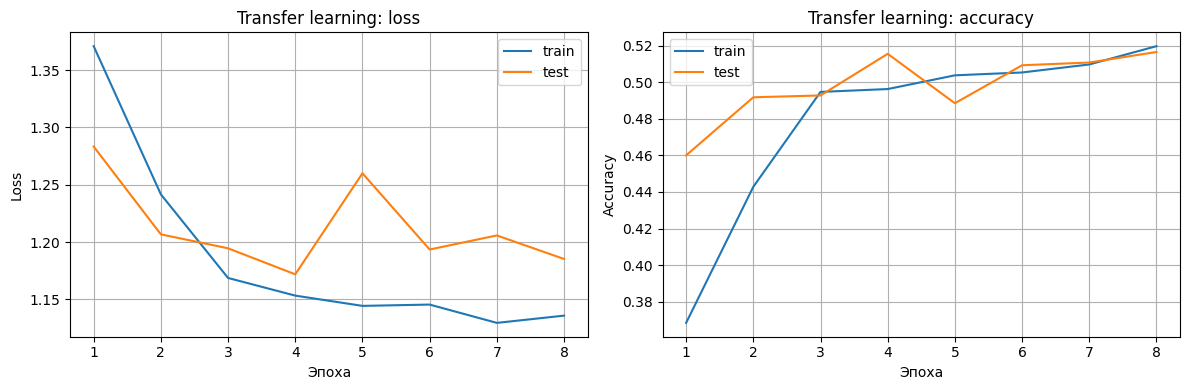

Итоговая точность TL: train=0.5197, test=0.5165


In [17]:
epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_tl, history_tl["train_loss"], label="train")
plt.plot(epochs_tl, history_tl["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tl, history_tl["train_acc"], label="train")
plt.plot(epochs_tl, history_tl["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность TL: train={history_tl['train_acc'][-1]:.4f}, test={history_tl['test_acc'][-1]:.4f}")

### Краткий анализ TL‑кривых

Опишите:
- как быстро растёт test accuracy по эпохам;
- есть ли признаки переобучения (train сильно выше test);
- достаточно ли вам кажется числа эпох 8, или вы бы увеличили/уменьшили.


In [18]:
tl_comment = """"По результатам видно, что модель начинает обучаться довольно быстро в первые несколько эпох. Уже к 3–4 эпохе test accuracy достигает примерно 0.49–0.51, а к 8 эпохе выходит на уровень около 0.5165. Дальше рост практически останавливается.
Если сравнить с обучением на 30 эпохах, видно, что увеличение числа эпох почти не дает ничего. максимальная test accuracy остается примерно на уровне 0.53 (лучшие значения около 0.5387), а итоговое значение даже немного падает до 0.5132. То есть после первых 5–8 эпох модель фактически перестаёт улучшаться.
Признаков сильного переобучения нет, train accuracy остаётся близкой к test, поэтому разрыв между ними небольшой. Это означает, что модель не запоминает train, а скорее недообучается.
По loss видно, что train loss немного снижается, но test loss колеблется и не показывает стабильного улучшения. Это ещё раз подтверждает, что замороженные слои плохо адаптируются к новой задаче.
В итоге можно сказать, что для этой настройки 8 эпох вполне достаточно, а увеличение до 30 эпох не имеет смысла. Чтобы улучшить результат, нужно не увеличивать число эпох, а переходить к частичному или полному дообучению сети."""
print(tl_comment)

"По результатам видно, что модель начинает обучаться довольно быстро в первые несколько эпох. Уже к 3–4 эпохе test accuracy достигает примерно 0.49–0.51, а к 8 эпохе выходит на уровень около 0.5165. Дальше рост практически останавливается.
Если сравнить с обучением на 30 эпохах, видно, что увеличение числа эпох почти не дает ничего. максимальная test accuracy остается примерно на уровне 0.53 (лучшие значения около 0.5387), а итоговое значение даже немного падает до 0.5132. То есть после первых 5–8 эпох модель фактически перестаёт улучшаться.
Признаков сильного переобучения нет, train accuracy остаётся близкой к test, поэтому разрыв между ними небольшой. Это означает, что модель не запоминает train, а скорее недообучается.
По loss видно, что train loss немного снижается, но test loss колеблется и не показывает стабильного улучшения. Это ещё раз подтверждает, что замороженные слои плохо адаптируются к новой задаче.
В итоге можно сказать, что для этой настройки 8 эпох вполне достаточно, а

## 7. Обучение похожей модели "с нуля" (без предобученных весов)

Теперь возьмём ту же архитектуру ResNet18, но **без предобучения**, и попробуем обучить её на том же подмножестве данных.

Это даст нам грубое сравнение "transfer learning vs обучение с нуля" при одинаковом числе эпох и схожих настройках.


In [20]:
scratch_model = models.resnet18(weights=None)
scratch_model.fc = nn.Linear(scratch_model.fc.in_features, num_target_classes)
scratch_model = scratch_model.to(device)

optimizer_scratch = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)

def train_one_epoch_scratch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_scratch(model, dataloader, criterion, device):
    return evaluate_tl(model, dataloader, criterion, device)

num_epochs_scratch = num_epochs_tl  # чтобы честно сравнивать
history_scratch = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_scratch + 1):
    train_loss, train_acc = train_one_epoch_scratch(scratch_model, train_loader, optimizer_scratch, criterion, device)
    test_loss, test_acc = evaluate_scratch(scratch_model, test_loader, criterion, device)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["test_loss"].append(test_loss)
    history_scratch["test_acc"].append(test_acc)

    print(f"[Scratch] Эпоха {epoch}/{num_epochs_scratch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[Scratch] Эпоха 1/8: train_loss=1.3839, train_acc=0.4088, test_loss=1.2982, test_acc=0.4475
[Scratch] Эпоха 2/8: train_loss=1.2065, train_acc=0.4744, test_loss=1.1683, test_acc=0.5058
[Scratch] Эпоха 3/8: train_loss=1.1032, train_acc=0.5250, test_loss=1.0744, test_acc=0.5447
[Scratch] Эпоха 4/8: train_loss=1.0815, train_acc=0.5431, test_loss=1.0620, test_acc=0.5470
[Scratch] Эпоха 5/8: train_loss=1.0267, train_acc=0.5650, test_loss=1.0146, test_acc=0.5663
[Scratch] Эпоха 6/8: train_loss=0.9991, train_acc=0.5622, test_loss=0.9818, test_acc=0.5985
[Scratch] Эпоха 7/8: train_loss=0.9604, train_acc=0.5944, test_loss=1.0408, test_acc=0.5813
[Scratch] Эпоха 8/8: train_loss=0.9583, train_acc=0.6056, test_loss=1.1291, test_acc=0.5653


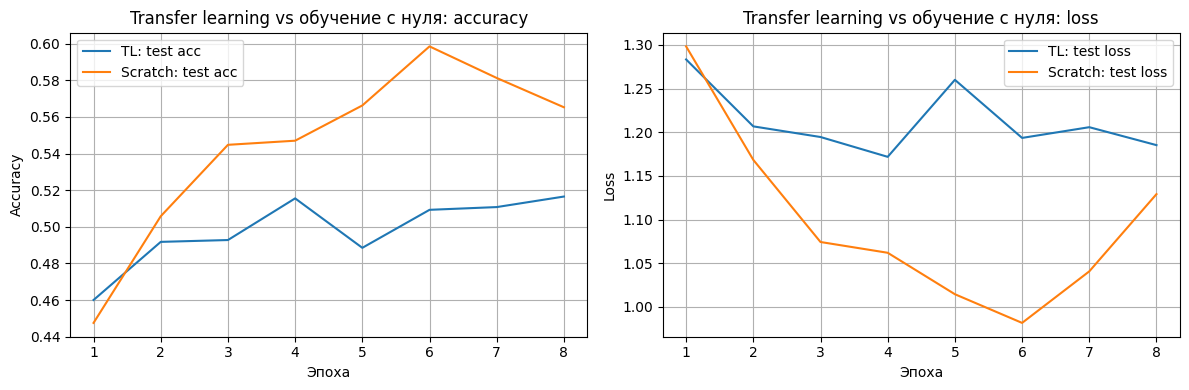

Финальная test accuracy (TL)     : 0.5165
Финальная test accuracy (Scratch): 0.5653


In [21]:
epochs = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_tl["test_acc"], label="TL: test acc")
plt.plot(epochs, history_scratch["test_acc"], label="Scratch: test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning vs обучение с нуля: accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_tl["test_loss"], label="TL: test loss")
plt.plot(epochs, history_scratch["test_loss"], label="Scratch: test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning vs обучение с нуля: loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная test accuracy (TL)     : {history_tl['test_acc'][-1]:.4f}")
print(f"Финальная test accuracy (Scratch): {history_scratch['test_acc'][-1]:.4f}")

## 8. Ваш анализ: transfer learning против обучения с нуля

Здесь особенно важно написать **свой** анализ, а не универсальные фразы.  
Ориентировочно ответьте:

- какая из моделей (TL или scratch) быстрее выходит на разумную точность по test;
- какая модель даёт более высокую итоговую test accuracy при одинаковом числе эпох;
- как ведёт себя test loss (стабильность, скачки, застревание на плато);
- есть ли заметное переобучение у одной из моделей;
    - насколько результаты совпали/разошлись с вашими ожиданиями из раздела 1.


In [22]:
comparison_comment = """По результатам видно, что в начале обучения transfer learning даёт более быстрый старт, на 1 эпохе test accuracy у TL около 0.46 против 0.4475 у модели с нуля, и в первые 2–3 эпохи TL держится немного лучше.
Дальше ситуация меняется, модель, обучаемая с нуля, начинает обгонять TL. Уже к 3–4 эпохе scratch достигает 0.5447–0.5470, в то время как TL остаётся 0.49–0.51. К 6 эпохе scratch выходит на 0.5985, тогда как TL остаётся примерно на уровне 0.51.
Итоговая test accuracy тоже выше у модели с нуля, 0.5653 против 0.5165 у transfer learning. Это означает, что в данном эксперименте обучение с нуля оказалось более эффективным.
По loss видно, что у TL кривая более плоская и почти не улучшается после первых эпох,что говорит о том, что замороженные слои плохо адаптируются к новой задаче. У scratch loss сначала стабильно падает (до 0.98 на 6эпохе),а затем начинает расти, что уже похоже на начало переобучения.
Сильного переобучения у TL нет, потому что модель в целом недообучается, train и test остаются на уровне 0.52. У scratch наоборот видно, что после 6 эпохи начинается ухудшение test loss,хотя accuracy остаётся относительно высокой.
Результаты частично не совпали с ожиданиями, я ожидала, что transfer learning будет явно лучше, но на практике модель с замороженными слоями оказалась слишком жёсткой и не смогла хорошо адаптироваться к выбранным классам.
В итоге можно сделать вывод, что transfer learning полезен для быстрого старта,но при сильном отличии задачи или малом числе обучаемых параметровон может уступать обучению с нуля."""
print(comparison_comment)

По результатам видно, что в начале обучения transfer learning даёт более быстрый старт, на 1 эпохе test accuracy у TL около 0.46 против 0.4475 у модели с нуля, и в первые 2–3 эпохи TL держится немного лучше.
Дальше ситуация меняется, модель, обучаемая с нуля, начинает обгонять TL. Уже к 3–4 эпохе scratch достигает 0.5447–0.5470, в то время как TL остаётся 0.49–0.51. К 6 эпохе scratch выходит на 0.5985, тогда как TL остаётся примерно на уровне 0.51.
Итоговая test accuracy тоже выше у модели с нуля, 0.5653 против 0.5165 у transfer learning. Это означает, что в данном эксперименте обучение с нуля оказалось более эффективным.
По loss видно, что у TL кривая более плоская и почти не улучшается после первых эпох,что говорит о том, что замороженные слои плохо адаптируются к новой задаче. У scratch loss сначала стабильно падает (до 0.98 на 6эпохе),а затем начинает расти, что уже похоже на начало переобучения.
Сильного переобучения у TL нет, потому что модель в целом недообучается, train и test 

## 8.5. (Задание со звездочкой) Почему transfer learning не сработал?

Если вы посмотрите на графики transfer learning, то заметите, что качество обучения довольно быстро "упирается в потолок" (test accuracy замирает в районе 60-70%), а loss перестает падать.
Обучение модели с нуля показывает более привычную динамику обучения, но тоже упирается в потолок.

**Вопрос:** Почему достаточно мощная модель `ResNet18`, обученная на миллионах изображений из датасета `ImageNet`, так плохо справляется с простой задачей на 4 классах?

Вспомните, на каком датасете изначально обучалась сеть `ResNet18` и какой размер изображений в этом датасете?
Какой размер изображений в датасете `CIFAR-10`?
Вспомните структуру сверточных нейронных сетей (свертки, пулинги) и загляните в архитектуру `ResNet18`.
Что происходит с пространственным размером картинки по мере прохождения через слои сети?
Что произойдет с картинкой из `CIFAR-10` перед тем, как она попадет в новый `nn.Linear` слой?

### Ваша задача:
1. **Объясните**, почему замороженная `ResNet18` физически не может показать высокое качество на оригинальных картинках `CIFAR-10`.
2. **Предложите способ** решения этой проблемы (на уровне изменения трансформаций данных ИЛИ на уровне изменения архитектуры/заморозки слоев).
3. **Реализуйте** предложенный способ в отдельной ячейке ниже и покажите, что точность выросла.

*Примечание - можно гуглить и спрашивать LLM*

In [ ]:
star_answer = """ЗДЕСЬ НАПИШИТЕ ВАШИ ОТВЕТЫ:
"""
print(star_answer)

In [ ]:
# TODO: Реализуйте способ решения проблемы с transfer learning

## 9. Итоговые выводы по лабораторной

В заключение сформулируйте короткое резюме (5–8 предложений):
- в каких случаях вы после этой работы **в первую очередь** будете пробовать transfer learning и почему;
- когда, по вашему мнению, имеет смысл всё-таки обучать модель с нуля (и зачем);
- какие настройки (заморозка слоёв, lr, число эпох, размер подвыборки) вы считаете для себя "разумными по умолчанию" после проведённых экспериментов.

Пишите так, чтобы вы сами, открыв этот ноутбук через полгода, смогли быстро вспомнить, что вы поняли про transfer learning.


In [23]:
final_summary = """В этой лабораторной я увидела, что transfer learning хорошо работает как быстрый старт, но не всегда даёт лучший итоговый результат. В моём случае модель с замороженными слоями быстро выходила на уровень около 0.5 по test accuracy, но дальше почти не улучшалась.
Обучение с нуля показало более медленную, но стабильную динамику и в итоге дало более высокую точность(около 0.56 против 0.51 у transfer learning). Это значит, что если задача отличается от исходнойили данных не так мало, обучение с нуля может быть более эффективным.
Теперь я бы в первую очередь использовала transfer learning, если данных очень мало или нужно быстро получить базовое решение. Но если качество важно и есть возможность обучать дольше,я бы попробовала дообучение всей сети или даже обучение с нуля.
Я бы сначала заморозила слои и обучила только последний, использовала небольшой learning rate (например, 1e-3),и обучать 5–10 эпох. Если качество не растёт, то переходить к разморозке слоёв.
Главный вывод для меня, что transfer learning это инструмент, который хорошо работает при правильных условиях, но требует адаптации под конкретную задачу."""
print(final_summary)

В этой лабораторной я увидела, что transfer learning хорошо работает как быстрый старт, но не всегда даёт лучший итоговый результат. В моём случае модель с замороженными слоями быстро выходила на уровень около 0.5 по test accuracy, но дальше почти не улучшалась.
Обучение с нуля показало более медленную, но стабильную динамику и в итоге дало более высокую точность(около 0.56 против 0.51 у transfer learning). Это значит, что если задача отличается от исходнойили данных не так мало, обучение с нуля может быть более эффективным.
Теперь я бы в первую очередь использовала transfer learning, если данных очень мало или нужно быстро получить базовое решение. Но если качество важно и есть возможность обучать дольше,я бы попробовала дообучение всей сети или даже обучение с нуля.
Я бы сначала заморозила слои и обучила только последний, использовала небольшой learning rate (например, 1e-3),и обучать 5–10 эпох. Если качество не растёт, то переходить к разморозке слоёв.
Главный вывод для меня, что tr